# Incremental Capstone Unit 2

**Instructor:** Abishek Ganesh

**Your Name:** David Fekke  
**Your Role:** Data Scientist  
**Client:** ShopSmart (a growing retail chain)  
**Due Date:** January 19th, 2025

---

## Project Brief

Welcome to your **Incremental Capstone Unit 2**! ShopSmart was so impressed with your Python tools from Unit 1 that they've hired you again. This time, they have a much larger challenge: a messy sales dataset with **500 transactions** that needs to be cleaned, explored, and prepared for their upcoming machine learning initiative.

Your mission is to transform this raw, messy data into a clean, ML-ready dataset. The data science team will use your prepared data in Unit 3 to build predictive models.

### The Data Problems You'll Face
- **Missing values** in several columns
- **Duplicate transactions** that slipped through their system
- **Messy text** with inconsistent spacing and capitalization
- **Outliers** that look like data entry errors
- **Categorical columns** that need to be converted to numbers for ML
- **Different scales** across numeric columns

---

### Rules & Integrity
1.  **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.
2.  **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, pitch solutions, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own**.
3.  **Use Your Resources**: You are free to use Google, StackOverflow, Pandas documentation, and your class notes.
4.  **Comment Your Code**: You must include comments explaining *why* you are doing what you are doing. I want to see your thought process.
5.  **Submission**: You may submit this assignment multiple times for feedback before the deadline.

### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [4]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition

Before diving into the data, take a moment to think about what you're trying to accomplish.

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** What is the main goal of this capstone? What will the data science team use your cleaned data for?

**Question 2:** Why can't we just feed the raw CSV file directly into a machine learning model? List at least 3 problems that would occur.

*(Double-click here to write your answers)*

**Answer 1:** The main goal of this capstone is to teach how to analyze, clean and prepare data for data science or machine learning applications.

**Answer 2:** Incomplete data with null or empty values can cause errors if you try to process those rows. It is also important to normalize the data so results do not skew due to spikes in any values. Some values will need to be converted to numbers from categories into either boolean or floating point values.


---

## Part 2: Data Loading

**The Problem:** ShopSmart has given you their sales data in a CSV file. Your first task is to load it and take an initial look.

**Your Task:** Create a function that loads the data and returns a DataFrame.

### Example Verification
```python
df = load_sales_data('shopsmart_sales.csv')
print(df.shape)  # Should print (500, 13)
```

In [5]:
def load_sales_data(filepath):
    """
    Load sales data from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    df = pd.read_csv(filepath)
    return df

In [6]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_sales_data('shopsmart_sales.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (500, 13), f"Expected shape (500, 13), got {df.shape}"
print("[PASS] Part 2 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

[PASS] Part 2 Tests Passed!

Dataset loaded: 500 rows, 13 columns


In [7]:
# Take a first look at the data
df.head(10)

,transaction_id,customer_id,date,product_category,product_name,quantity,unit_price,total_amount,payment_method,store_location,customer_age,is_member,customer_tier
0,1165,109,2024-08-24,Home & Garden,plant pot,4,133.08,532.32,Credit Card,Mall,29.0,Yes,Bronze
1,1384,127,2024-03-01,Electronics,Headphones,3,257.78,773.34,Debit Card,Suburb,68.0,Yes,Platinum
2,1046,211,2024-11-27,Clothing,jeans,1,261.80,261.80,Credit Card,Suburb,34.0,No,Silver
3,1157,188,2024-03-19,Electronics,Smart Watch,4,292.36,1169.44,Credit Card,Mall,53.0,Yes,Silver
4,1054,180,2024-09-12,Electronics,tablet,3,289.74,869.22,Credit Card,Downtown,22.0,Yes,Bronze
5,1073,211,2024-05-29,Sports,Tennis Racket,1,225.66,225.66,Cash,Airport,54.0,Yes,Bronze
6,1316,230,2024-09-17,Clothing,jeans,2,198.61,397.22,Mobile Payment,Online,70.0,No,Bronze
7,1210,129,2024-12-27,Home & Garden,Lamp,5,387.31,1936.55,Cash,Online,32.0,No,Gold
8,1075,198,2024-05-19,Home & Garden,PILLOW,1,296.35,296.35,Credit Card,Suburb,34.0,Yes,Silver
9,1334,247,2024-07-31,Home & Garden,Lamp,1,252.73,252.73,Debit Card,Mall,44.0,Yes,Silver


In [8]:
# Check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   date              500 non-null    object 
 3   product_category  500 non-null    object 
 4   product_name      500 non-null    object 
 5   quantity          500 non-null    int64  
 6   unit_price        475 non-null    float64
 7   total_amount      475 non-null    float64
 8   payment_method    500 non-null    object 
 9   store_location    460 non-null    object 
 10  customer_age      485 non-null    float64
 11  is_member         500 non-null    object 
 12  customer_tier     500 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 50.9+ KB


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Looking at the output of `df.info()`, what problems do you already notice with this data? (Hint: Look at non-null counts and data types)

The `unit_price` and `total_amount` both have about 25 missing rows from the CSV. The `customer_age` is missing about 15 rows and the `store_location` is missing 40 rows. There are a number of columns are objects or strings that need to be one hotted or categorized so they can be processed numerically in a ML model.

---

## Part 3: Data Quality Assessment

**The Problem:** Before cleaning, we need to know exactly what's wrong with the data. ShopSmart's manager wants a summary report.

**Your Task:** Create a function that analyzes the data and returns a quality report.

### Example Verification
```python
report = check_data_quality(df)
print(report['total_missing'])     # Should be > 0
print(report['duplicate_count'])   # Should be 15
```

In [9]:
def check_data_quality(df):
    """
    Analyze data quality and return a summary report.
    
    Args:
        df (pd.DataFrame): The DataFrame to analyze
        
    Returns:
        dict: A dictionary containing:
            - 'total_rows': Total number of rows
            - 'total_columns': Total number of columns  
            - 'missing_by_column': Dict of {column: missing_count}
            - 'total_missing': Total missing values across all columns
            - 'duplicate_count': Number of duplicate rows (based on transaction_id)
            - 'data_types': Dict of {column: dtype}
    """
    # I am returning a dictionary with the data quality results.
    return {
        'total_rows': df.shape[0],
        'total_columns': df.shape[1],
        'missing_by_column': df.isnull().sum().to_dict(),
        'total_missing': df.isnull().sum().sum(),
        'duplicate_count': df.duplicated(subset=['transaction_id']).sum(),
        'data_types': df.dtypes.apply(lambda x: x.name).to_dict()
    }

In [10]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Run the quality check
report = check_data_quality(df)

# Basic Verification
assert report is not None, "Function returned None"
assert isinstance(report, dict), "Function should return a dictionary"
assert 'total_rows' in report, "Missing 'total_rows' key"
assert 'missing_by_column' in report, "Missing 'missing_by_column' key"
assert 'duplicate_count' in report, "Missing 'duplicate_count' key"
assert report['total_rows'] == 500, f"Expected 500 rows, got {report['total_rows']}"
assert report['duplicate_count'] == 15, f"Expected 15 duplicates, got {report['duplicate_count']}"
assert report['total_missing'] > 0, "There should be missing values in this dataset"
print("[PASS] Part 3 Tests Passed!")

# Display the report
print("\n=== DATA QUALITY REPORT ===")
print(f"Total Rows: {report['total_rows']}")
print(f"Total Columns: {report['total_columns']}")
print(f"Duplicate Transactions: {report['duplicate_count']}")
print(f"Total Missing Values: {report['total_missing']}")
print("\nMissing by Column:")
for col, count in report['missing_by_column'].items():
    if count > 0:
        print(f"  - {col}: {count}")

[PASS] Part 3 Tests Passed!

=== DATA QUALITY REPORT ===
Total Rows: 500
Total Columns: 13
Duplicate Transactions: 15
Total Missing Values: 105

Missing by Column:
  - unit_price: 25
  - total_amount: 25
  - store_location: 40
  - customer_age: 15


---

## Part 4: Data Cleaning

**The Problem:** Now we need to fix all the issues we found. This is the most critical step!

**Your Task:** Create a function that:
1. Removes duplicate transactions (keep the first occurrence)
2. Handles missing values appropriately:
   - For numeric columns: fill with the **median**
   - For categorical columns: fill with the **mode** (most common value)
3. Cleans the `product_name` column (strip whitespace, convert to lowercase)
4. Removes outliers in `customer_age` (keep only ages between 10 and 100)

### Example Verification
```python
df_clean = clean_data(df)
print(df_clean.shape)                    # Should be less than (500, 12) - duplicates removed
print(df_clean.isnull().sum().sum())     # Should be 0 - no missing values
print(df_clean['product_name'].iloc[0])  # Should be lowercase with no extra spaces
```

In [11]:
def clean_data(df):
    """
    Clean the sales data.
    
    Steps:
    1. Remove duplicate transactions (based on transaction_id)
    2. Fill missing numeric values with median
    3. Fill missing categorical values with mode
    4. Clean product_name (strip whitespace, lowercase)
    5. Remove outliers in customer_age (keep 10-100)
    
    Args:
        df (pd.DataFrame): The raw DataFrame
        
    Returns:
        pd.DataFrame: The cleaned DataFrame
    """
    # IMPORTANT: Make a copy first so we don't modify the original!
    df_clean = df.copy()

    print(f"Duplicate rows: {df_clean.duplicated().sum()}")
    # df_clean = df_clean.drop_duplicates()
    df_clean = df_clean.drop_duplicates(subset="transaction_id", keep='first')

    print(f"Shape after removing duplicates: {df_clean.shape}")
    
    # Your code here
    # Step 1: Remove duplicates
    df_clean = df_clean.drop_duplicates(subset=["transaction_id"])
    
    # Step 2: Fill missing numeric values with median
    # Hint: Use df_clean.select_dtypes(include=[np.number]).columns to get numeric columns
    df_clean["unit_price"] = df_clean["unit_price"].fillna(
        df_clean["unit_price"].median()
    )

    df_clean["total_amount"] = df_clean["total_amount"].fillna(
        df_clean["total_amount"].median()
    )

    df_clean["customer_age"] = df_clean["customer_age"].fillna(
        df_clean["customer_age"].median()
    )
    
    # Step 3: Fill missing categorical values with mode
    # Hint: Use df_clean.select_dtypes(include=['object']).columns to get categorical columns
    df_clean["store_location"] = df_clean["store_location"].fillna(
        df_clean["store_location"].mode()[0]
    )

    # Step 4: Clean product_name
    df_clean["product_name"] = df_clean["product_name"].str.lower().replace(
        r"^\s+|\s+$", "", regex=True
    )
    
    # Step 5: Remove outliers in customer_age
    return df_clean[(df_clean['customer_age'] <= 100) & (df_clean['customer_age'] >= 10)]


In [12]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Clean the data
df_clean = clean_data(df)

# Basic Verification
assert df_clean is not None, "Function returned None"
assert isinstance(df_clean, pd.DataFrame), "Function should return a DataFrame"
assert len(df_clean) < 500, "Duplicates should have been removed"
assert df_clean.isnull().sum().sum() == 0, f"Still have {df_clean.isnull().sum().sum()} missing values!"
assert df_clean['product_name'].str.contains(r'^\s|\s$').sum() == 0, "Product names still have leading/trailing spaces"
assert df_clean['product_name'].str.isupper().sum() == 0, "Product names should be lowercase"
assert df_clean['customer_age'].min() >= 10, "Outliers below 10 should be removed"
assert df_clean['customer_age'].max() <= 100, "Outliers above 100 should be removed"
print("[PASS] Part 4 Tests Passed!")

print(f"\nOriginal rows: 500")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

Duplicate rows: 0
Shape after removing duplicates: (485, 13)
[PASS] Part 4 Tests Passed!

Original rows: 500
Cleaned rows: 475
Missing values: 0


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Why did we fill missing numeric values with the **median** instead of the **mean**? When would the mean be a poor choice?

The median value is a better choice for prices and age because it is the middle value of spread of numbers, and would be more realistic and a stable number for training data. The mean is an average value and is unrealistic. The mean can also shift or skew the value while the median stays centered.

---

## Part 5: Summary Statistics

**The Problem:** ShopSmart wants to understand the distribution of their sales data. Create a function that calculates key statistics for any numeric column.

**Your Task:** Create a function that returns a dictionary of statistics.

### Example Verification
```python
stats = get_summary_statistics(df_clean, 'total_amount')
print(stats['mean'])    # The average transaction amount
print(stats['median'])  # The middle value
print(stats['std'])     # Standard deviation
```

In [15]:
def get_summary_statistics(df, column):
    """
    Calculate summary statistics for a numeric column.
    
    Args:
        df (pd.DataFrame): The DataFrame
        column (str): The column name to analyze
        
    Returns:
        dict: A dictionary containing:
            - 'count': Number of values
            - 'mean': Average value
            - 'median': Middle value
            - 'std': Standard deviation
            - 'min': Minimum value
            - 'max': Maximum value
            - 'q1': 25th percentile
            - 'q3': 75th percentile
    """
    # I am creating a summary of statistics into a dictionary. 
    statistics_dictionary = {
        "count": df[column].count(),
        "mean": df[column].mean(),
        "median": df[column].median(),
        "std": df[column].std(),
        "min": df[column].min(),
        "max": df[column].max(),
        "q1": df[column].quantile(0.25),
        "q3": df[column].quantile(0.75)
    }

    # Returning the dictionary of the summary values.
    return statistics_dictionary

In [16]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Get statistics for total_amount
stats = get_summary_statistics(df_clean, 'total_amount')

# Basic Verification
assert stats is not None, "Function returned None"
assert isinstance(stats, dict), "Function should return a dictionary"
required_keys = ['count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3']
for key in required_keys:
    assert key in stats, f"Missing '{key}' in stats dictionary"
assert stats['min'] <= stats['q1'] <= stats['median'] <= stats['q3'] <= stats['max'], "Statistics don't make sense"
print("[PASS] Part 5 Tests Passed!")

# Display the statistics
print("\n=== TOTAL AMOUNT STATISTICS ===")
for key, value in stats.items():
    print(f"  {key}: {value:.2f}")

[PASS] Part 5 Tests Passed!

=== TOTAL AMOUNT STATISTICS ===
  count: 475.00
  mean: 707.06
  median: 568.14
  std: 543.15
  min: 6.22
  max: 2396.15
  q1: 274.87
  q3: 989.83


---

## Part 6: Exploratory Data Analysis (Visualizations)

**The Problem:** Numbers are great, but ShopSmart's executives want to *see* the data. Create 4 visualizations to help them understand the patterns.

**Your Task:** Create the following 4 plots using the cleaned data:

1. **Histogram** - Distribution of `total_amount`
2. **Correlation Heatmap** - Relationships between numeric columns
3. **Bar Chart** - Count of transactions by `product_category`
4. **Box Plot** - `total_amount` by `product_category` (to spot outliers)

### 6.1 Histogram: Distribution of Total Amount

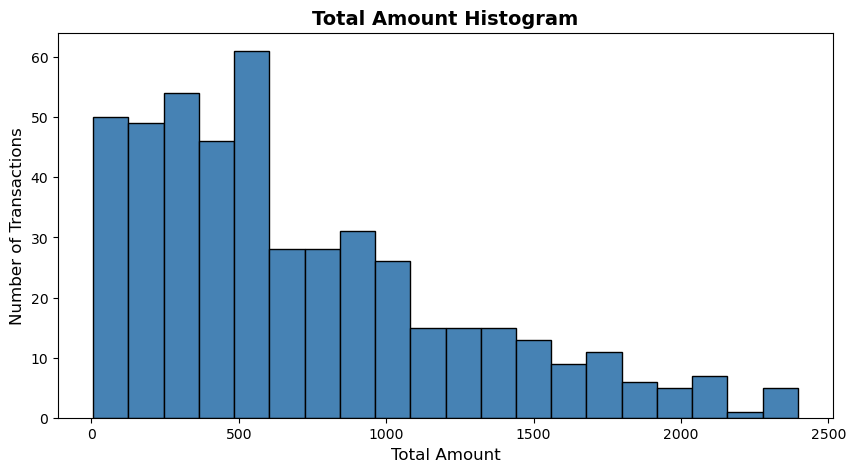

In [17]:
# Create a histogram showing the distribution of total_amount
# Hint: Use plt.hist() or df_clean['total_amount'].hist()
# Make sure to add:
#   - A title
#   - X-axis label
#   - Y-axis label

# Your code here
plt.figure(figsize=(10, 5))

# bins = how many "buckets" to divide the data into
plt.hist(df_clean['total_amount'].dropna(), bins=20, color='steelblue', edgecolor='black')

plt.title('Total Amount Histogram', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.show()

### 6.2 Correlation Heatmap

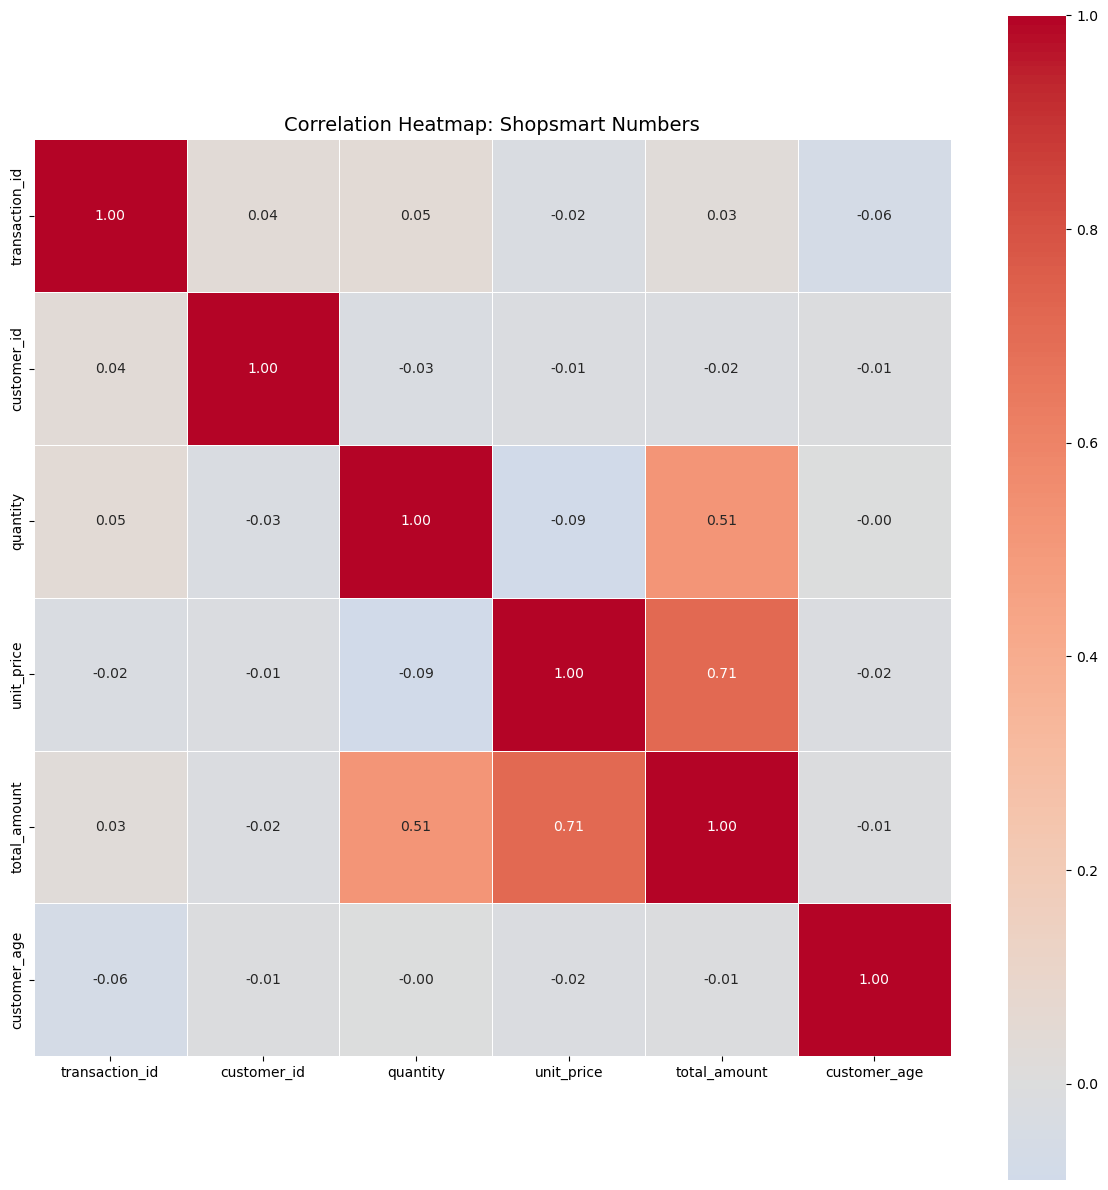

In [14]:
# Create a correlation heatmap for numeric columns
# Hint: Use sns.heatmap() with df_clean.select_dtypes(include=[np.number]).corr()
# Make sure to add:
#   - A title
#   - Annotations (annot=True)
#   - A good color scheme (cmap='coolwarm' works well)

plt.figure(figsize=(12, 12))

# Select only numeric columns for correlation
numeric_df = df_clean.select_dtypes(include=['number'])

# Create the heatmap
sns.heatmap(numeric_df.corr(), 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Make cells square
            linewidths=0.5)       # Add grid lines

plt.title('Correlation Heatmap: Shopsmart Numbers', fontsize=14)
plt.tight_layout()
plt.show()


### 6.3 Bar Chart: Transactions by Category

Text(0, 0.5, 'Count')

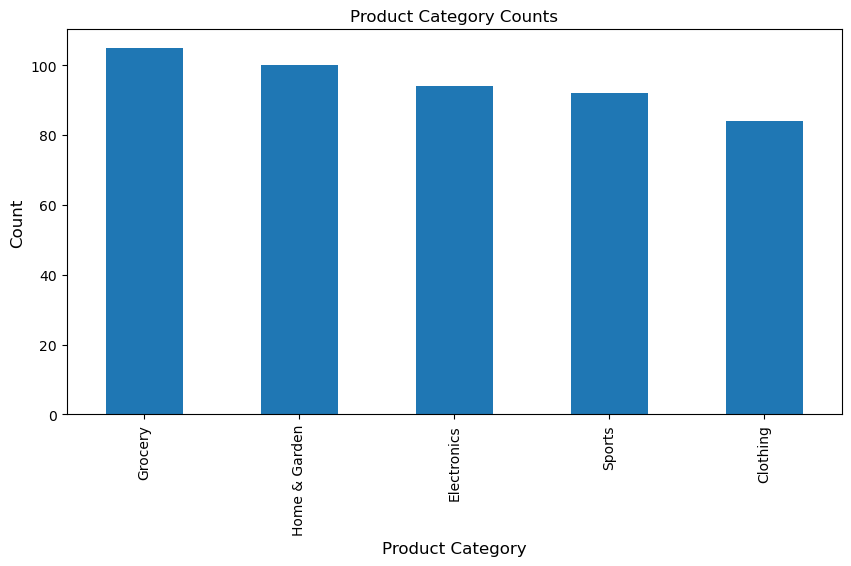

In [19]:
# Create a bar chart showing the count of transactions per product_category
# Hint: Use df_clean['product_category'].value_counts().plot(kind='bar')
# Or use sns.countplot()
# Make sure to add:
#   - A title
#   - X-axis label
#   - Y-axis label

# Creating a bar chart of the product categories.
plt.figure(figsize=(10, 5))
plt.title("Product Category Counts")

df_clean['product_category'].value_counts().plot(kind='bar')
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Count", fontsize=12)

### 6.4 Box Plot: Total Amount by Category

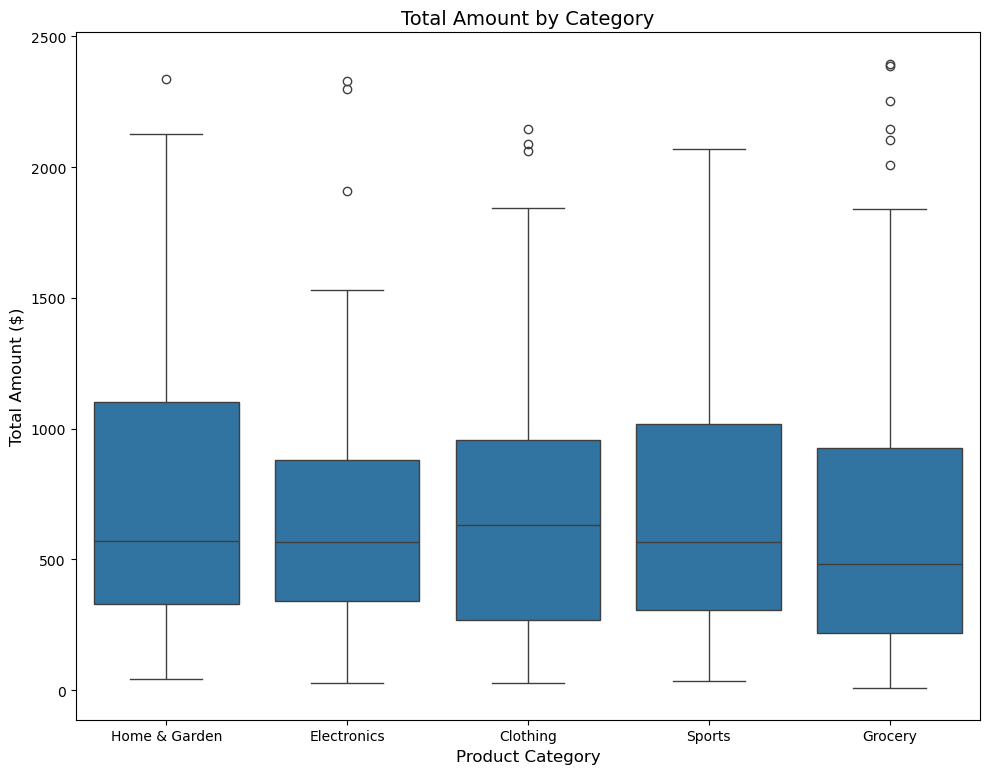

In [20]:
# Create a box plot showing total_amount distribution for each product_category
# Hint: Use sns.boxplot(x='product_category', y='total_amount', data=df_clean)
# Make sure to add:
#   - A title
#   - Rotate x-axis labels if they overlap (plt.xticks(rotation=45))

# Your code here
plt.figure(figsize=(10, 8))
sns.boxplot(x='product_category', y='total_amount', data=df_clean)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Amount ($)', fontsize=12)
plt.title('Total Amount by Category', fontsize=14)
plt.suptitle('')  # Remove automatic title
plt.tight_layout()

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Looking at your histogram, is the distribution of `total_amount` symmetric or skewed? What does this tell you about customer purchasing behavior?

**Question 2:** Looking at your correlation heatmap, which two variables have the strongest positive correlation? Does this relationship make logical sense?

*(Double-click here to write your answers)*

**Answer 1:** The total amount is skewed and not symmetric. It is skewed towards lower priced purchases.

**Answer 2:** The unit price and the total amount have a correlation of 0.71. This makes since because they are both related to the price. 


---

## Part 7: Encode Categorical Columns

**The Problem:** Machine learning models need numbers, not text! We need to convert categorical columns into numeric format. But there are **two different methods** depending on the type of categorical data:

### Two Types of Categorical Data:

| Type | Description | Example | Encoding Method |
|------|-------------|---------|-----------------|
| **Ordinal** | Has a meaningful order | Bronze < Silver < Gold < Platinum | **Label Encoding** (0, 1, 2, 3) |
| **Nominal** | No inherent order | Red, Blue, Green | **One-Hot Encoding** (separate columns) |

### Your Dataset Has Both Types:
- `customer_tier` → **Ordinal** (Bronze < Silver < Gold < Platinum) → Use Label Encoding
- `product_category`, `payment_method`, `store_location`, `is_member` → **Nominal** → Use One-Hot Encoding

---

### 7a: Label Encoding (for Ordinal Data)

**Your Task:** Create a function that converts `customer_tier` to numbers while preserving the order.

| Tier | Encoded Value |
|------|---------------|
| Bronze | 0 |
| Silver | 1 |
| Gold | 2 |
| Platinum | 3 |

In [21]:
def label_encode_ordinal(df, column, order):
    """
    Label encode an ordinal categorical column.
    
    Args:
        df (pd.DataFrame): The DataFrame
        column (str): The column name to encode
        order (list): The ordered list of categories (lowest to highest)
                      e.g., ['Bronze', 'Silver', 'Gold', 'Platinum']
        
    Returns:
        pd.DataFrame: DataFrame with the column label encoded
    """
    # IMPORTANT: Make a copy first!
    df_encoded = df.copy()
    
    # Your code here
    # Hint: Create a mapping dictionary like {'Bronze': 0, 'Silver': 1, ...}
    mapping = {}
    for index, item in enumerate(order):
        mapping[item] = index

    # Then use df_encoded[column].map(mapping)
    df_encoded[column] = df_encoded[column].map(mapping)

    return df_encoded


In [22]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Label encode customer_tier
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
df_label_encoded = label_encode_ordinal(df_clean, 'customer_tier', tier_order)

# Basic Verification
assert df_label_encoded is not None, "Function returned None"
assert df_label_encoded['customer_tier'].dtype in ['int64', 'int32', 'float64'], "customer_tier should be numeric"
assert df_label_encoded['customer_tier'].min() == 0, "Bronze should be encoded as 0"
assert df_label_encoded['customer_tier'].max() == 3, "Platinum should be encoded as 3"
print("[PASS] Part 7a Label Encoding Tests Passed!")

print("\nLabel Encoding Result:")
print(f"  Bronze (0): {(df_label_encoded['customer_tier'] == 0).sum()} customers")
print(f"  Silver (1): {(df_label_encoded['customer_tier'] == 1).sum()} customers")
print(f"  Gold (2): {(df_label_encoded['customer_tier'] == 2).sum()} customers")
print(f"  Platinum (3): {(df_label_encoded['customer_tier'] == 3).sum()} customers")

[PASS] Part 7a Label Encoding Tests Passed!

Label Encoding Result:
  Bronze (0): 201 customers
  Silver (1): 155 customers
  Gold (2): 84 customers
  Platinum (3): 35 customers


### 7b: One-Hot Encoding (for Nominal Data)

**Your Task:** Create a function that performs one-hot encoding on the nominal categorical columns.

### Example:
```
Before: product_category = "Electronics"
After:  product_category_Electronics = 1
        product_category_Clothing = 0
        product_category_Grocery = 0
        ...
```

In [23]:
def one_hot_encode_nominal(df, columns):
    """
    One-hot encode the specified nominal categorical columns.
    
    Args:
        df (pd.DataFrame): The DataFrame
        columns (list): List of column names to encode
        
    Returns:
        pd.DataFrame: DataFrame with encoded columns
                      (original categorical columns should be removed)
    """
    # IMPORTANT: Make a copy first!
    df_encoded = df.copy()

    # Your code here
    # Hint: Use pd.get_dummies(df_encoded, columns=columns)
    df_encoded = pd.get_dummies(df_encoded, columns=columns)
    return df_encoded

In [24]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# One-hot encode nominal columns (use the label-encoded dataframe!)
nominal_columns = ['product_category', 'payment_method', 'store_location', 'is_member']
df_encoded = one_hot_encode_nominal(df_label_encoded, nominal_columns)

# Basic Verification
assert df_encoded is not None, "Function returned None"
assert 'product_category' not in df_encoded.columns, "Original 'product_category' column should be removed"
assert 'payment_method' not in df_encoded.columns, "Original 'payment_method' column should be removed"
# Check that new encoded columns exist
encoded_cols = [col for col in df_encoded.columns if 'product_category_' in col]
assert len(encoded_cols) > 0, "No encoded product_category columns found"
# Check that customer_tier is still numeric (from label encoding)
assert df_encoded['customer_tier'].dtype in ['int64', 'int32', 'float64'], "customer_tier should still be numeric"
print("[PASS] Part 7b One-Hot Encoding Tests Passed!")

print(f"\nAfter label encoding: {len(df_label_encoded.columns)} columns")
print(f"After one-hot encoding: {len(df_encoded.columns)} columns")
print(f"\nSample of new columns:")
for col in list(df_encoded.columns)[:10]:
    print(f"  - {col}")

[PASS] Part 7b One-Hot Encoding Tests Passed!

After label encoding: 13 columns
After one-hot encoding: 25 columns

Sample of new columns:
  - transaction_id
  - customer_id
  - date
  - product_name
  - quantity
  - unit_price
  - total_amount
  - customer_age
  - customer_tier
  - product_category_Clothing


### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Why did we use **Label Encoding** for `customer_tier` but **One-Hot Encoding** for `product_category`? What's the key difference between these two columns?

**Question 2:** What would go wrong if we used Label Encoding for `product_category`? (Hint: Think about what the numbers would mean to the ML model.)

*(Double-click here to write your answers)*

**Answer 1:** `customer_tier` values have higher and lower values depending on the label. Because of these labels have higher orders, we can assign a number to the label. The `product_category` does not correspond to a numerical value so we use one hot encoding to create new columns set to a boolean value. 

**Answer 2:** The `product_category` column does not have a numerical value. A ML model will handle these values better if we one hot encode them into a new column.

---

## Part 8: Scale Numeric Columns

**The Problem:** Our numeric columns have very different scales. `customer_age` ranges from 10-100, while `total_amount` can be in the thousands. This can confuse ML models!

**Your Task:** Create a function that scales numeric columns to a 0-1 range using Min-Max scaling.

### Formula
```
scaled_value = (value - min) / (max - min)
```

### Example Verification
```python
df_scaled = scale_numeric_columns(df_encoded, ['customer_age', 'total_amount'])
print(df_scaled['customer_age'].min())  # Should be 0.0
print(df_scaled['customer_age'].max())  # Should be 1.0
```

In [25]:
# Creating a function that I can reuse for calculating the min max scale.
def min_max_scale(df):
    return (df - df.min()) / (df.max() - df.min())

def scale_numeric_columns(df, columns):
    """
    Scale specified numeric columns to 0-1 range using Min-Max scaling.
    
    Formula: scaled = (value - min) / (max - min)
    
    Args:
        df (pd.DataFrame): The DataFrame
        columns (list): List of column names to scale
        
    Returns:
        pd.DataFrame: DataFrame with scaled columns
    """
    # IMPORTANT: Make a copy first!
    df_scaled = df.copy()
    
    # Your code here
    # For each column in columns:
    #   Apply the min-max scaling formula
    for col in columns:
        df_scaled[col] = min_max_scale(df_scaled[col])
                                       
    return df_scaled

In [26]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Scale numeric columns
columns_to_scale = ['quantity', 'unit_price', 'total_amount', 'customer_age']
df_scaled = scale_numeric_columns(df_encoded, columns_to_scale)

# Basic Verification
assert df_scaled is not None, "Function returned None"
for col in columns_to_scale:
    assert df_scaled[col].min() >= 0, f"{col} has values below 0"
    assert df_scaled[col].max() <= 1, f"{col} has values above 1"
    assert abs(df_scaled[col].min() - 0) < 0.01, f"{col} minimum should be ~0"
    assert abs(df_scaled[col].max() - 1) < 0.01, f"{col} maximum should be ~1"
print("[PASS] Part 8 Tests Passed!")

print("\nScaled column ranges:")
for col in columns_to_scale:
    print(f"  {col}: [{df_scaled[col].min():.3f}, {df_scaled[col].max():.3f}]")

[PASS] Part 8 Tests Passed!

Scaled column ranges:
  quantity: [0.000, 1.000]
  unit_price: [0.000, 1.000]
  total_amount: [0.000, 1.000]
  customer_age: [0.000, 1.000]


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Why is it important to scale features to a similar range before training a machine learning model? What could go wrong if we didn't scale?

In machine learning it is important to `normalize` the data, otherwise this could cause skewed values to prevent our models from making correct predictions.

---

## Part 9: Prepare Final ML-Ready DataFrame

**The Problem:** We've done all the hard work! Now we need to put it all together and create the final DataFrame that the data science team will use in Unit 3.

**Your Task:** Create a function that:
1. Drops columns that aren't useful for ML (like `transaction_id`, `date`, `product_name`, `customer_id`)
2. Ensures ALL columns are numeric
3. Ensures there are NO missing values

### Example Verification
```python
final_df = prepare_ml_dataframe(df_scaled)
print(final_df.select_dtypes(exclude=[np.number]).columns)  # Should be empty
print(final_df.isnull().sum().sum())                        # Should be 0
```

In [27]:
def prepare_ml_dataframe(df):
    """
    Prepare the final ML-ready DataFrame.
    
    Steps:
    1. Drop non-useful columns: transaction_id, date, product_name, customer_id
    2. Verify all columns are numeric
    3. Verify no missing values
    
    Args:
        df (pd.DataFrame): The processed DataFrame
        
    Returns:
        pd.DataFrame: The final ML-ready DataFrame
    """
    # IMPORTANT: Make a copy first!
    final_df = df.copy()
    
    # Your code here
    # Step 1: Drop non-useful columns
    columns_to_drop = ['transaction_id', 'date', 'product_name', 'customer_id']
    final_df = final_df.drop(columns=columns_to_drop)
    
    return final_df

In [28]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Prepare the final ML-ready DataFrame
final_df = prepare_ml_dataframe(df_scaled)

# Basic Verification
assert final_df is not None, "Function returned None"
assert 'transaction_id' not in final_df.columns, "transaction_id should be dropped"
assert 'date' not in final_df.columns, "date should be dropped"
assert 'product_name' not in final_df.columns, "product_name should be dropped"
assert 'customer_id' not in final_df.columns, "customer_id should be dropped"
non_numeric = final_df.select_dtypes(exclude=[np.number, np.bool]).columns.tolist()
assert len(non_numeric) == 0, f"All columns should be numeric, but found: {non_numeric}"
assert final_df.isnull().sum().sum() == 0, "There should be no missing values"
print("[PASS] Part 9 Tests Passed!")

print(f"\nFinal ML-Ready DataFrame:")
print(f"  Rows: {len(final_df)}")
print(f"  Columns: {len(final_df.columns)}")
print(f"  All numeric: True")
print(f"  Missing values: 0")

[PASS] Part 9 Tests Passed!

Final ML-Ready DataFrame:
  Rows: 475
  Columns: 21
  All numeric: True
  Missing values: 0


In [29]:
# Preview the final DataFrame
final_df.head(10)

,quantity,unit_price,total_amount,customer_age,customer_tier,product_category_Clothing,product_category_Electronics,product_category_Grocery,product_category_Home & Garden,product_category_Sports,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_Mobile Payment,store_location_Airport,store_location_Downtown,store_location_Mall,store_location_Online,store_location_Suburb,is_member_No,is_member_Yes
0,0.75,0.257964,0.220132,0.211538,0,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True
1,0.50,0.510184,0.320980,0.961538,3,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True
2,0.00,0.518315,0.106940,0.307692,1,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False
3,0.75,0.580126,0.486717,0.673077,1,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True
4,0.50,0.574827,0.361098,0.076923,0,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True
5,0.00,0.445218,0.091819,0.692308,0,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True
6,0.25,0.390506,0.163603,1.000000,0,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
7,1.00,0.772173,0.807693,0.269231,2,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False
8,0.00,0.588196,0.121397,0.307692,1,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True
9,0.00,0.499970,0.103145,0.500000,1,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True


---

## Final Summary

Run this cell to see a summary of your entire data pipeline!

In [30]:
print("="*60)
print("DATA PIPELINE SUMMARY")
print("="*60)
print(f"\n1. ORIGINAL DATA")
print(f"   Rows: 500")
print(f"   Columns: 12")
print(f"   Issues: Missing values, duplicates, messy text, outliers")

print(f"\n2. AFTER CLEANING")
print(f"   Rows: {len(df_clean)}")
print(f"   Missing values: {df_clean.isnull().sum().sum()}")
print(f"   Duplicates removed: {500 - len(df_clean)}")

print(f"\n3. AFTER ENCODING")
print(f"   Columns: {len(df_encoded.columns)}")
print(f"   Categorical columns converted to numeric")

print(f"\n4. AFTER SCALING")
print(f"   All numeric columns now in 0-1 range")

print(f"\n5. FINAL ML-READY DATA")
print(f"   Rows: {len(final_df)}")
print(f"   Columns: {len(final_df.columns)}")
print(f"   All numeric: True")
print(f"   Missing values: 0")
print(f"   Ready for machine learning: YES!")
print("\n" + "="*60)

DATA PIPELINE SUMMARY

1. ORIGINAL DATA
   Rows: 500
   Columns: 12
   Issues: Missing values, duplicates, messy text, outliers

2. AFTER CLEANING
   Rows: 475
   Missing values: 0
   Duplicates removed: 25

3. AFTER ENCODING
   Columns: 25
   Categorical columns converted to numeric

4. AFTER SCALING
   All numeric columns now in 0-1 range

5. FINAL ML-READY DATA
   Rows: 475
   Columns: 21
   All numeric: True
   Missing values: 0
   Ready for machine learning: YES!



---

## Final Written Reflection

> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Looking back at this entire pipeline, which step do you think was the most important? Why?

**Question 2:** If ShopSmart gave you a brand new dataset next month, what would you do differently? What did you learn that would make the process faster?

**Question 3:** The final DataFrame is ready for machine learning. What kind of predictions do you think ShopSmart might want to make with this data? (There's no wrong answer - just think about what would be valuable for a retail business.)

**Answer 1:** Normalizing the data so that it would be more useful for data predictions.

**Answer 2:** I would change some of the functions so they would perform data cleaning based on data type so the code would be more reusable.

**Answer 3:** Which customer type and which retail type have higher sales. Knowing this will tailor marketing for the business.


---

## Ready to Submit?

### Checklist:
- [ ] All **assert tests pass** (no errors when running the test cells)
- [ ] All **4 visualizations** are created and display correctly
- [ ] All **Written Reflections** are answered thoughtfully
- [ ] Code has **comments** explaining your logic
- [ ] No debugging print statements left in the code

### Submission:
Turn in your completed notebook on Canvas by **January 19th, 2025**.

Remember: You can resubmit after receiving feedback up until the due date!

---

*Great work making it through Unit 2! In Unit 3, you'll use this prepared data to build actual machine learning models.*